# Common Test I: Multi-Class Classification
## ML4SCI DeepLense Foundation Model (GSoC 2026)
## By Muhammed Razan

This Notebook contains detailed information regarding experiments from test 1.


In [ ]:
!pip install -q einops timm tqdm 2>/dev/null || true


Exception ignored in: <function tqdm.__del__ at 0x7c203d007600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
import os, sys, json, time, math, random, warnings, zipfile, glob
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter
import shutil

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import torchvision.models as models
import torchvision.transforms as transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, auc, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm

matplotlib.rcParams.update(
    {'figure.dpi': 120, 'savefig.dpi': 150,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'figure.titlesize': 14}
)
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
@dataclass
class Config:
    data_root: str = "./dataset"
    classes: tuple = ("no_sub", "subhalo", "vortex")
    num_classes: int = 3
    img_size: int = 224 # Up-sampled for transfer learning
    val_split: float = 0.10
    seed: int = 42

    arcsinh_a: float = 5.0
    noise_std: float = 0.005

    batch_size: int = 64
    num_epochs: int = 30
    lr: float = 1e-4
    weight_decay: float = 0.05
    warmup_epochs: int = 5
    min_lr: float = 1e-6
    label_smoothing: float = 0.1
    grad_clip: float = 1.0
    use_amp: bool = True

    ckpt_dir: str = "./checkpoints"
    drive_ckpt_dir: str = "/content/drive/MyDrive/DeepLense_GsoC/checkpoints"
    fig_dir: str = "./figures"
    num_workers: int = 2

    def __post_init__(self):
        os.makedirs(self.ckpt_dir, exist_ok=True)
        os.makedirs(self.fig_dir, exist_ok=True)
        os.makedirs(self.drive_ckpt_dir, exist_ok=True)

cfg = Config()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive_zip_path = Path("/content/drive/MyDrive/DeepLense_GsoC/dataset.zip")
local_zip_path = Path("/content/dataset.zip")
extract_to_dir = Path("./dataset")

if not extract_to_dir.exists():
    if drive_zip_path.exists():
        print(f"Copying {drive_zip_path.name} to local runtime...")
        shutil.copy(drive_zip_path, local_zip_path)
        print("Extracting...")
        with zipfile.ZipFile(local_zip_path, 'r') as z:
            z.extractall(extract_to_dir)
        local_zip_path.unlink()
        print("Done! Dataset is ready at:", extract_to_dir)
    else:
        print(f"Warning: Could not find zip at {drive_zip_path}. Please update cfg.data_root if needed.")
else:
    print(f"Dataset already exists at {extract_to_dir}")

cfg.data_root = str(extract_to_dir / "dataset")


Dataset already exists at dataset


In [ ]:
from pathlib import Path
import warnings
from collections import Counter
from sklearn.model_selection import train_test_split

def build_file_list(root, classes):
    files = []
    class_name_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    physical_dir_to_class_name = {"no": "no_sub", "sphere": "subhalo", "vort": "vortex"}

    for split_folder in ["train", "val"]:
        split_path = Path(root) / split_folder
        for physical_dir_name, class_display_name in physical_dir_to_class_name.items():
            class_path = split_path / physical_dir_name
            if not class_path.exists():
                warnings.warn(f"Warning: Class path {class_path} does not exist. Skipping.")
                continue
            label_idx = class_name_to_idx[class_display_name]
            for p in sorted(class_path.glob("*.npy")):
                files.append((str(p), label_idx))
    return files

all_files = build_file_list(cfg.data_root, cfg.classes)
labels = [l for _, l in all_files]

class_files_map = {cls_name: [] for cls_name in cfg.classes}
for filepath, label_idx in all_files:
    class_files_map[cfg.classes[label_idx]].append(filepath)


class_files_map has been re-created.


      no_sub: 12,500
     subhalo: 12,500
      vortex: 12,500
       Total: 37,500


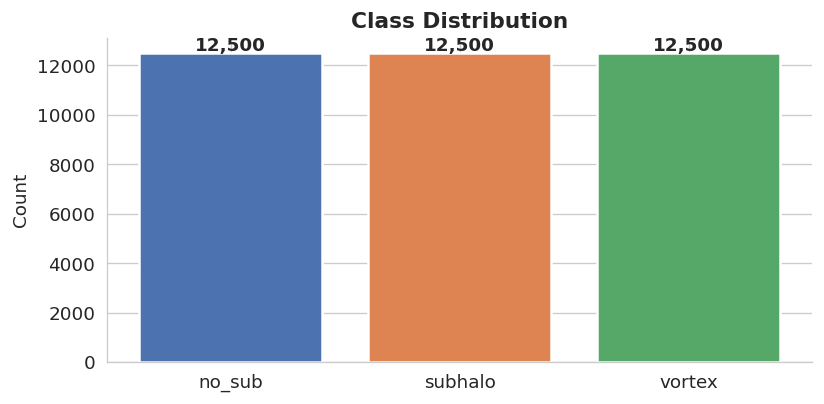

In [ ]:
def build_file_list(root, split, classes):
    files = []
    class_map = {"no": "no_sub", "sphere": "subhalo", "vort": "vortex"}
    class_idx = {cls: i for i, cls in enumerate(classes)}

    for orig, mapped in class_map.items():
        for p in sorted(Path(root, split, orig).glob("*.npy")):
            files.append((str(p), class_idx[mapped]))
    return files

train_files = build_file_list(cfg.data_root, "train", cfg.classes)
val_files = build_file_list(cfg.data_root, "val", cfg.classes)
all_files = train_files + val_files

class_files_map = {cls_name: [] for cls_name in cfg.classes}
for filepath, label_idx in all_files:
    class_files_map[cfg.classes[label_idx]].append(filepath)

counts = {cls: len(class_files_map[cls]) for cls in cfg.classes}
for cls in cfg.classes:
    print(f"  {cls:>10}: {counts[cls]:,}")
print(f"{'Total':>12}: {sum(counts.values()):,}")

fig, ax = plt.subplots(figsize=(7, 3.5))
colors_bar = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(counts.keys(), counts.values(), color=colors_bar, edgecolor='white', lw=1.5)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f'{v:,}', ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{cfg.fig_dir}/class_distribution.png', bbox_inches='tight'); plt.show()


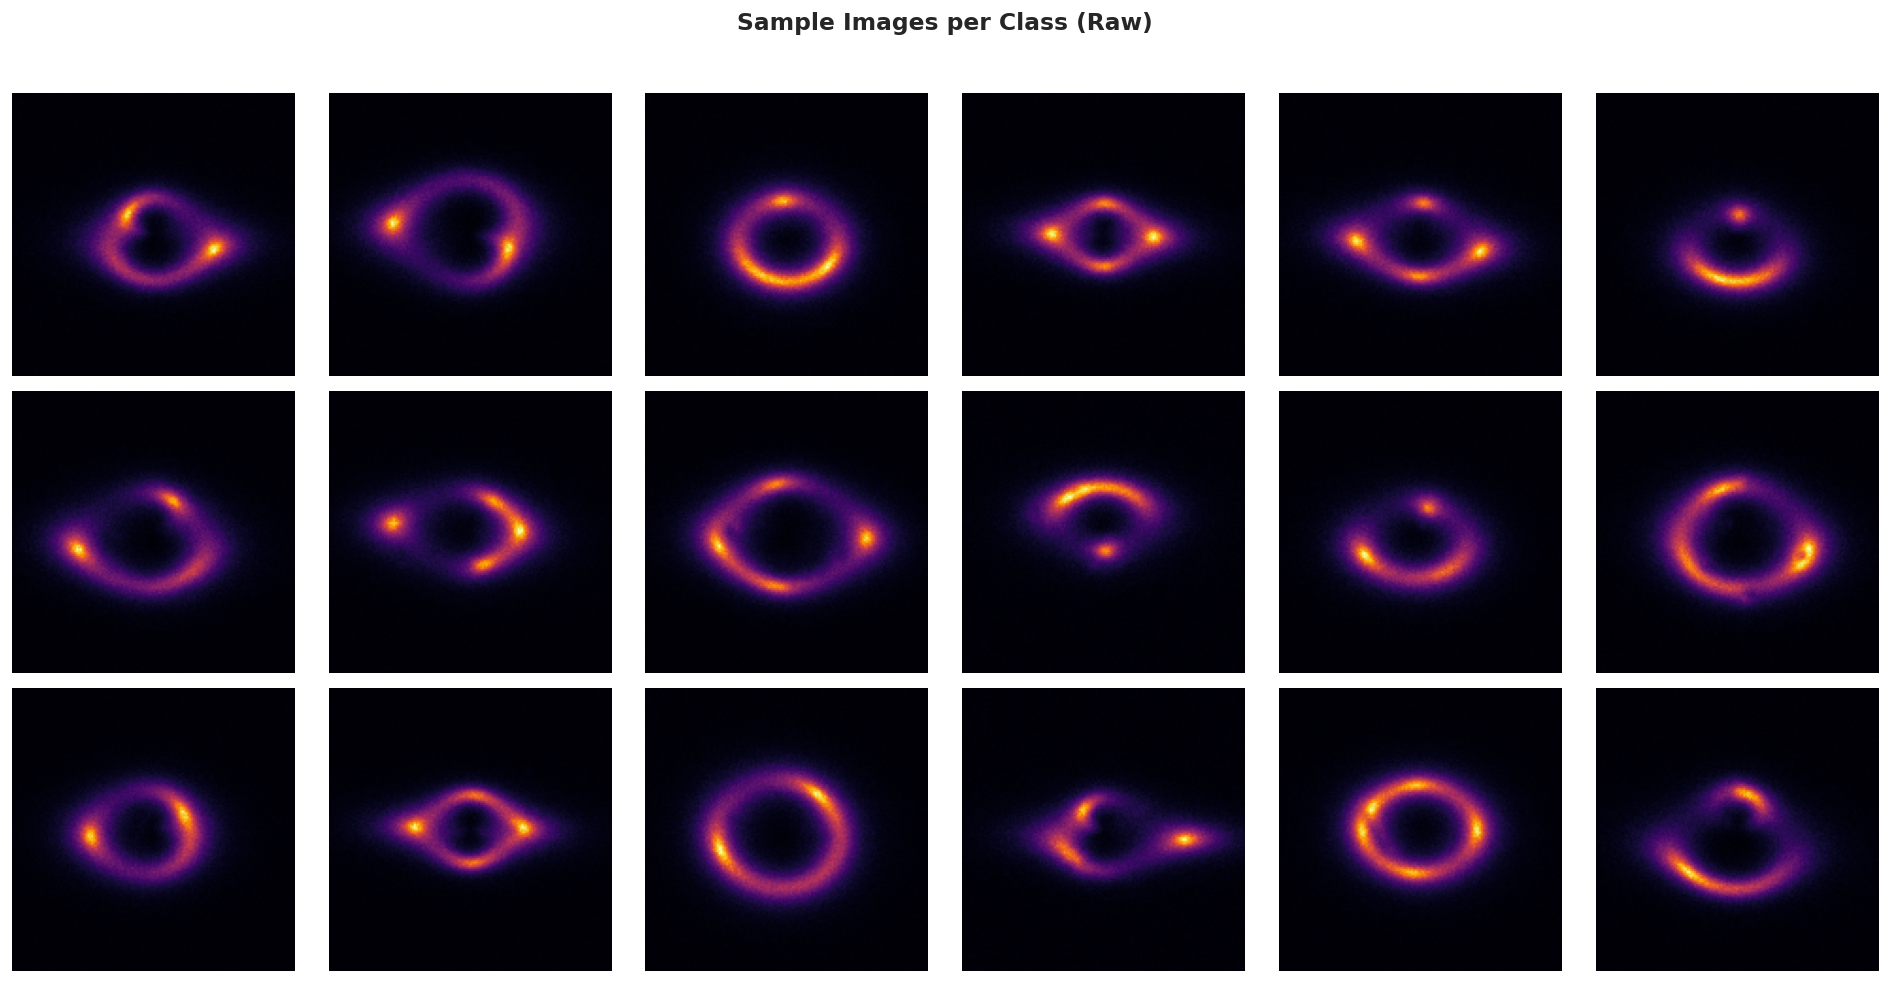

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Sample Images per Class (Raw)', fontsize=14, fontweight='bold', y=1.02)

for row, cls in enumerate(cfg.classes):
    files = class_files_map[cls]
    if not files: continue
    samples = random.sample(files, min(6, len(files)))
    for col, fp in enumerate(samples):
        img = np.load(fp)
        if img.ndim == 3:
            img = img.squeeze(0)
        axes[row, col].imshow(img, cmap='inferno', origin='lower')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=90, labelpad=40)
plt.tight_layout()
plt.savefig(f'{cfg.fig_dir}/sample_images_raw.png', bbox_inches='tight')
plt.show()


In [ ]:
def arcsinh_stretch(x: torch.Tensor, a: float = 5.0) -> torch.Tensor:
    s = torch.asinh(a * x)
    s_min, s_max = s.min(), s.max()
    return (s - s_min) / (s_max - s_min + 1e-8)

class LensingPreprocessor:
    def __init__(self, a: float = 5.0):
        self.a = a
    def __call__(self, img: np.ndarray) -> torch.Tensor:
        if img.ndim == 3: img = img.squeeze(0)
        img = np.clip(img.astype(np.float32), 0.0, None)
        vmin, vmax = img.min(), img.max()
        if vmax > vmin: img = (img - vmin) / (vmax - vmin)
        t = torch.from_numpy(img).unsqueeze(0)
        return arcsinh_stretch(t, self.a)

class PhysicsAugmentation:
    def __init__(self, noise_std: float = 0.005):
        self.noise_std = noise_std
        self.resize = transforms.Resize((cfg.img_size, cfg.img_size))
        self.normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

    def __call__(self, img: torch.Tensor, is_train: bool) -> torch.Tensor:
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        if is_train:
            k = random.randint(0, 3)
            img = torch.rot90(img, k, dims=[-2, -1])
            if random.random() > 0.5: img = torch.flip(img, [-1])
            if random.random() > 0.5: img = torch.flip(img, [-2])
            if self.noise_std > 0:
                img = torch.clamp(img + torch.randn_like(img) * self.noise_std, 0, 1)

        img = self.resize(img)
        img = self.normalize(img)
        return img


Alongside Standard Augmentations, (90deg rot, horizontal and vertical flips) I have incorporated a Preprocessing step:

ArcSinh Strech Formula:

\begin{equation}
    f(x) = \ln\left(a \cdot x + \sqrt{(a \cdot x)^2 + 1}\right)
\end{equation}

here $a = 5.0$ was used, it is the softening parameter controlling the degree of compression. This transformation suppresses bright arc saturation while simultaneously amplifying faint substructure signals in the low-intensity regime, making it particularly effective for differentiating dark-matter models that manifest as subtle perturbations to the lensing signal.

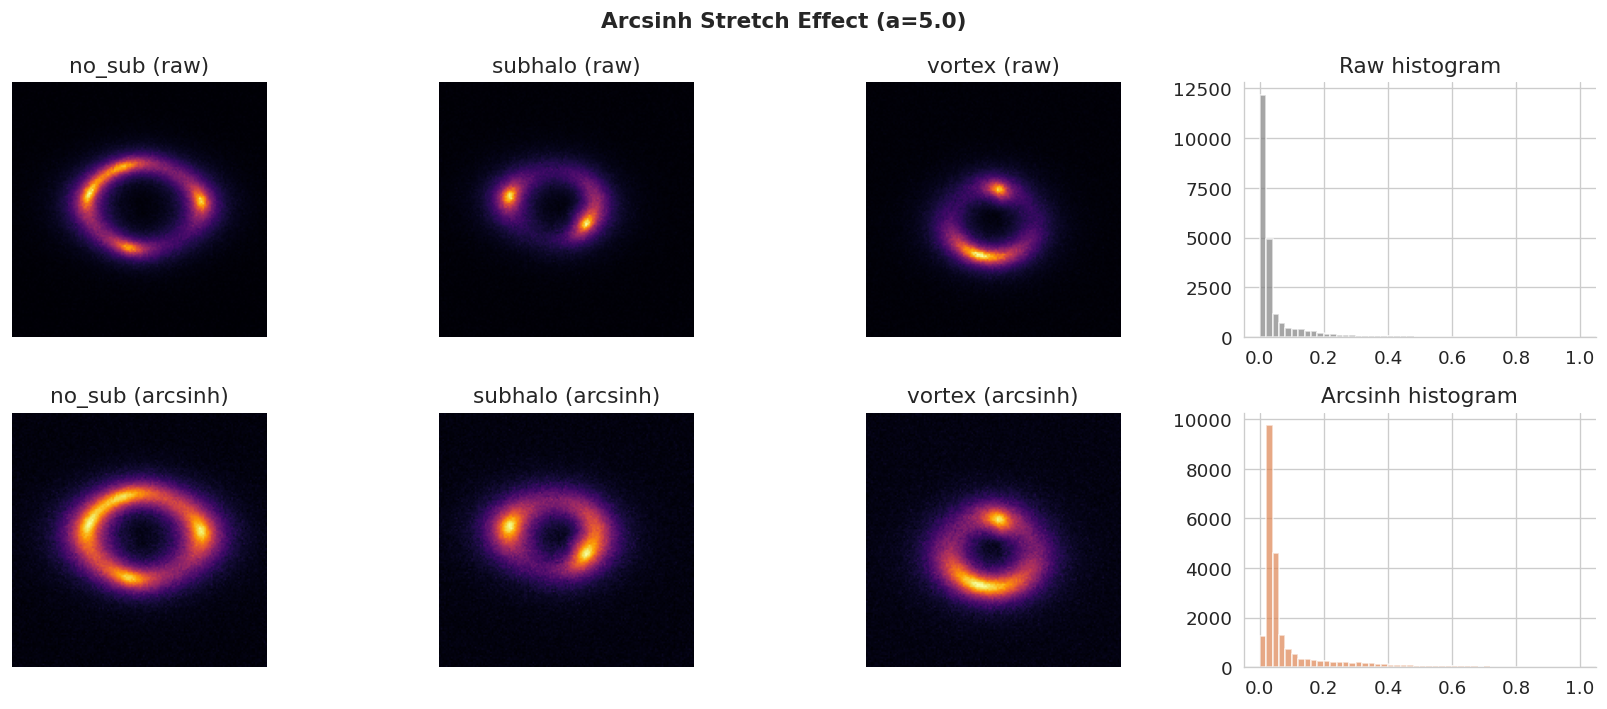

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Arcsinh Stretch Effect (a=5.0)', fontsize=13, fontweight='bold')
prep = LensingPreprocessor(a=cfg.arcsinh_a)
for col, cls in enumerate(cfg.classes):
    files = class_files_map[cls]
    if not files: continue
    fp = random.choice(files)
    raw = np.load(fp)
    if raw.ndim == 3: raw = raw.squeeze(0)
    stretched = prep(raw).squeeze(0).numpy()
    axes[0, col].imshow(raw, cmap='inferno', origin='lower')
    axes[0, col].set_title(f'{cls} (raw)'); axes[0, col].axis('off')

    axes[1, col].imshow(stretched, cmap='inferno', origin='lower')
    axes[1, col].set_title(f'{cls} (arcsinh)'); axes[1, col].axis('off')
raw_ex = np.load(fp).flatten()
str_ex = prep(np.load(fp)).flatten().numpy()
axes[0, 3].hist(raw_ex, bins=50, color='gray', alpha=0.7); axes[0, 3].set_title('Raw histogram')
axes[1, 3].hist(str_ex, bins=50, color='#DD8452', alpha=0.7); axes[1, 3].set_title('Arcsinh histogram')
for ax in axes[:, 3]: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{cfg.fig_dir}/arcsinh_effect.png', bbox_inches='tight')
plt.show()


In [ ]:
def get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs, min_lr_ratio=0.01):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return max(epoch / max(warmup_epochs, 1), 0.01)
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, cfg):
    model.train()
    total_loss, correct, n = 0., 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="  train", leave=False):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with autocast('cuda', enabled=cfg.use_amp and device.type == 'cuda'):
            logits = model(imgs)
            loss = criterion(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        correct += (logits.argmax(1) == labels).sum().item()
        n += bs
        all_probs.append(F.softmax(logits.detach().float(), dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc_val = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro') if len(np.unique(all_labels)) > 1 else 0.0
    return total_loss / n, correct / n, auc_val

@torch.no_grad()
def evaluate(model, loader, criterion, device, cfg):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="  val  ", leave=False):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with autocast('cuda', enabled=cfg.use_amp and device.type == 'cuda'):
            logits = model(imgs)
            loss = criterion(logits, labels)
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        correct += (logits.argmax(1) == labels).sum().item()
        n += bs
        all_probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc_val = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro') if len(np.unique(all_labels)) > 1 else 0.0
    return total_loss / n, correct / n, auc_val, all_probs, all_labels


In [ ]:
class LensingDataset(Dataset):
    def __init__(self, file_list, preprocessor, augmentation=None, is_train=True):
        self.files = file_list
        self.prep = preprocessor
        self.aug = augmentation
        self.is_train = is_train

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        path, label = self.files[idx]
        img = self.prep(np.load(path))
        if self.aug: img = self.aug(img, self.is_train)
        return img, label

def build_file_list(root, split, classes):
    """Scan and fetch exact files from physical 'split' directories."""
    files = []
    class_map = {"no": "no_sub", "sphere": "subhalo", "vort": "vortex"}
    class_idx = {cls: i for i, cls in enumerate(classes)}

    for orig, mapped in class_map.items():
        for p in sorted(Path(root, split, orig).glob("*.npy")):
            files.append((str(p), class_idx[mapped]))
    return files

train_files = build_file_list(cfg.data_root, "train", cfg.classes)
val_files = build_file_list(cfg.data_root, "val", cfg.classes)

if not train_files or not val_files:
    print(f"Dataset check - Train: {len(train_files)}, Val: {len(val_files)}. Ensure cfg.data_root is correct.")

preprocessor = LensingPreprocessor(a=cfg.arcsinh_a)
augmentation = PhysicsAugmentation(noise_std=cfg.noise_std)

train_ds = LensingDataset(train_files, preprocessor, augmentation, is_train=True)
val_ds   = LensingDataset(val_files, preprocessor, augmentation, is_train=False)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=True)

val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True) #


print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")


Train: 30,000 | Val: 7,500


I stuck to the datasets actual split of 30K and 7.5K images to prevent leakage from the val set into training.

In [ ]:
def run_training_loop(model, model_name="model"):
    class_counts = torch.tensor([
        sum(1 for _, l in train_files if l == i) for i in range(cfg.num_classes)
    ], dtype=torch.float32)
    if class_counts.sum() == 0: class_counts += 1.0
    class_weights = (class_counts.sum() / (cfg.num_classes * class_counts)).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg.label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = get_cosine_schedule_with_warmup(optimizer, cfg.warmup_epochs, cfg.num_epochs)
    scaler = GradScaler('cuda', enabled=cfg.use_amp and DEVICE.type == 'cuda')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_auc': [], 'val_auc': [], 'lr': []}
    best_auc = 0.0
    best_path = f"{cfg.ckpt_dir}/best_{model_name}.pth"
    drive_best_path = f"{cfg.drive_ckpt_dir}/best_{model_name}.pth"

    print(f"\n--- Training {model_name} ---")
    print(f"{'Ep':>3} {'TrLoss':>8} {'TrAcc':>7} {'TrAUC':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlAUC':>7} {'LR':>10}")
    print("-" * 75)

    for epoch in range(1, cfg.num_epochs + 1):
        tr_loss, tr_acc, tr_auc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE, cfg)
        vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE, cfg)
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)
        history['lr'].append(lr)

        flag = ""
        if vl_auc > best_auc:
            best_auc = vl_auc
            torch.save({'model_state': model.state_dict(), 'val_auc': vl_auc}, best_path)
            shutil.copy(best_path, drive_best_path)
            flag = " *"

        print(f"{epoch:>3} {tr_loss:>8.4f} {tr_acc:>7.3f} {tr_auc:>7.4f} "
              f"{vl_loss:>8.4f} {vl_acc:>7.3f} {vl_auc:>7.4f} {lr:>10.2e}{flag}")

    print(f"\nBest Validation AUC for {model_name}: {best_auc:.4f}")

    # Load Best Model for Return
    model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=False)['model_state'])
    _, _, _, all_probs, all_true = evaluate(model, val_loader, criterion, DEVICE, cfg)

    return model, history, all_probs, all_true

In [ ]:
def plot_learning_curves(history, model_name):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(epochs_range, history['train_loss'], 'o-', ms=3, label='Train', lw=2)
    axes[0].plot(epochs_range, history['val_loss'], 's--', ms=3, label='Val', lw=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Cross-Entropy Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history['train_auc'], 'o-', ms=3, label='Train', lw=2)
    axes[1].plot(epochs_range, history['val_auc'], 's--', ms=3, label='Val', lw=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro AUC')
    axes[1].set_title('Macro AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_range, history['lr'], 'g-', lw=2)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('LR Schedule'); axes[2].grid(alpha=0.3)

    plt.suptitle(f'Training Curves - {model_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cfg.fig_dir}/learning_curves_{model_name}.png', bbox_inches='tight')
    plt.show()

def plot_roc_curves(all_probs, all_true, model_name):
    all_true_bin = label_binarize(all_true, classes=[0, 1, 2])
    colors_roc = ['#4C72B0', '#DD8452', '#55A868']

    fig, ax = plt.subplots(figsize=(8, 7))
    aucs = {}
    for i, (cls, color) in enumerate(zip(cfg.classes, colors_roc)):
        fpr, tpr, _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        aucs[cls] = roc_auc_val
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls} (AUC = {roc_auc_val:.4f})')
    if len(np.unique(all_true)) > 1:
        macro_auc = roc_auc_score(all_true, all_probs, multi_class='ovr', average='macro')
        micro_auc = roc_auc_score(all_true_bin, all_probs, average='micro')
        ax.set_title(f'ROC Curves - {model_name}\nMacro AUC: {macro_auc:.4f} | Micro AUC: {micro_auc:.4f}',
                 fontsize=13, fontweight='bold')
    else:
        ax.set_title(f'ROC Curves - {model_name}', fontsize=13, fontweight='bold')

    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5, label='Random (0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right', fontsize=11, frameon=True)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{cfg.fig_dir}/roc_curves_{model_name}.png', bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(all_probs, all_true, model_name):
    all_pred_cls = np.argmax(all_probs, axis=1)
    cm = confusion_matrix(all_true, all_pred_cls)
    cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-8) * 100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cfg.classes, yticklabels=cfg.classes, ax=ax1, cbar_kws={'shrink': 0.8})
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
    ax1.set_title('Confusion Matrix (Counts)')
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=cfg.classes, yticklabels=cfg.classes, ax=ax2, cbar_kws={'shrink': 0.8})
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix (Row-Normalized %)')

    plt.suptitle(f'Classification Results - {model_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cfg.fig_dir}/confusion_matrix_{model_name}.png', bbox_inches='tight')
    plt.show()



--- Training ResNet34 ---
 Ep   TrLoss   TrAcc   TrAUC   VlLoss   VlAcc   VlAUC         LR
---------------------------------------------------------------------------


  train:   0%|          | 0/468 [00:00<?, ?it/s]

  val  :   0%|          | 0/118 [00:00<?, ?it/s]

  1   1.2538   0.336  0.5204   1.2443   0.339  0.5062   2.00e-05 *


  train:   0%|          | 0/468 [00:00<?, ?it/s]

...

 29   0.3252   0.983  0.9981   0.3581   0.969  0.9942   1.39e-06


  train:   0%|          | 0/468 [00:00<?, ?it/s]

  val  :   0%|          | 0/118 [00:00<?, ?it/s]

 30   0.3239   0.984  0.9983   0.3579   0.969  0.9943   1.00e-06

Best Validation AUC for ResNet34: 0.9947


  val  :   0%|          | 0/118 [00:00<?, ?it/s]

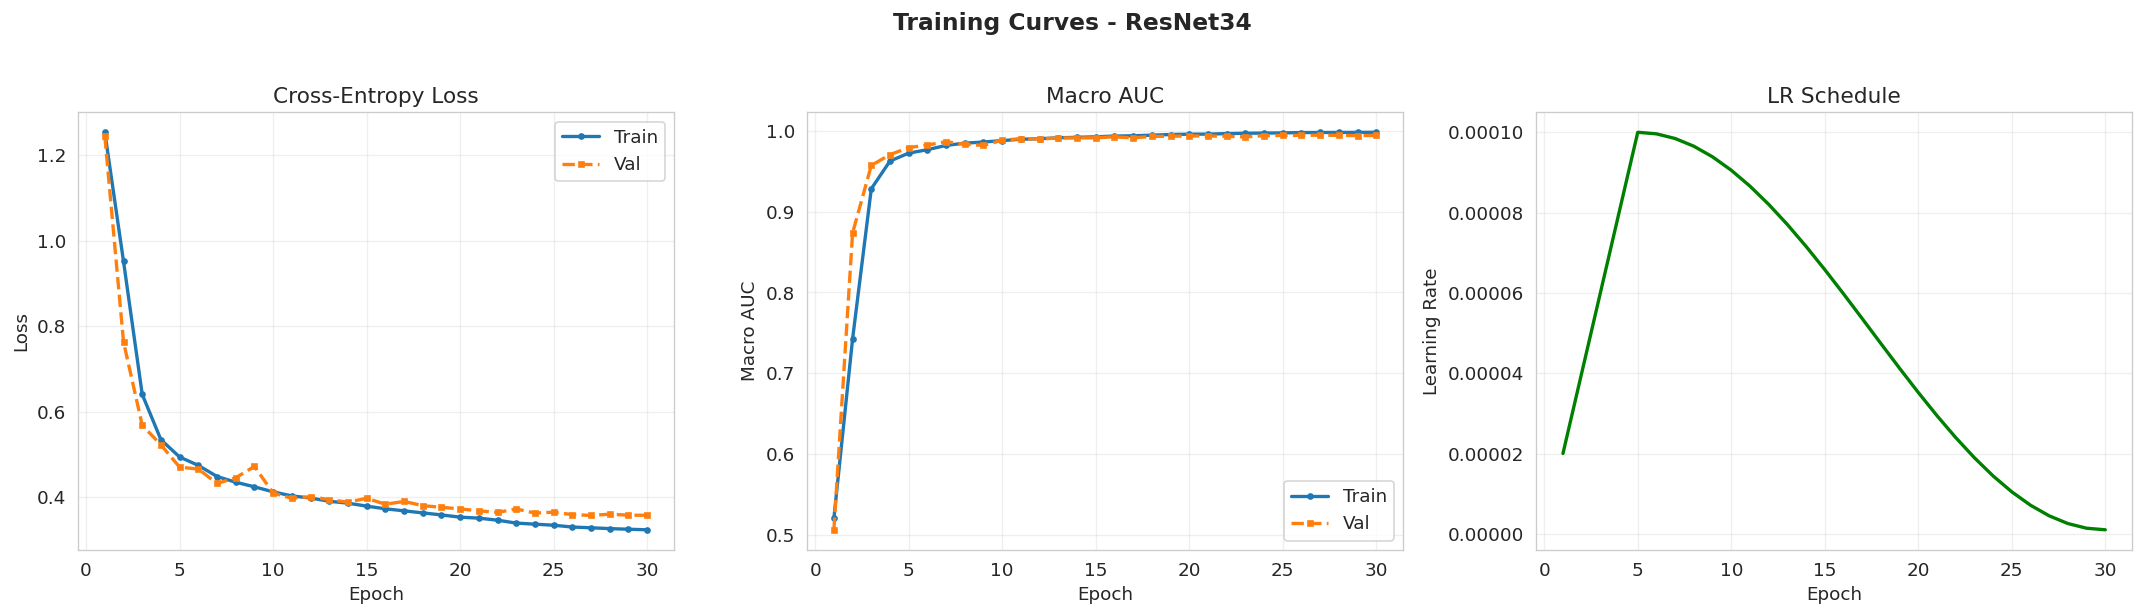

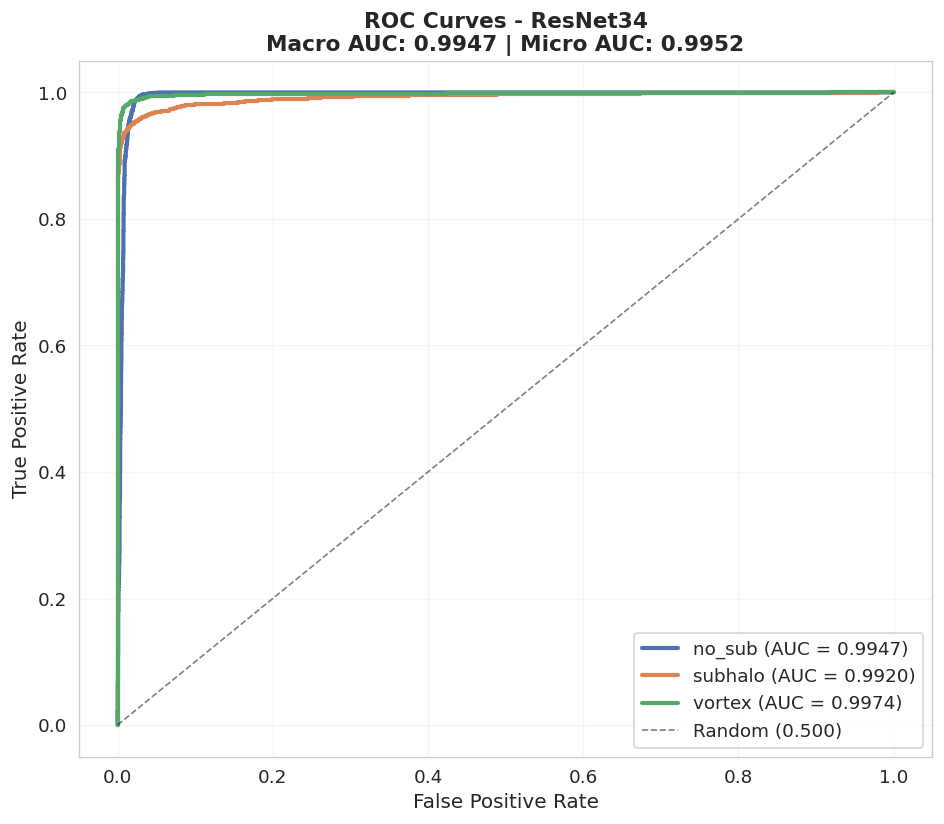

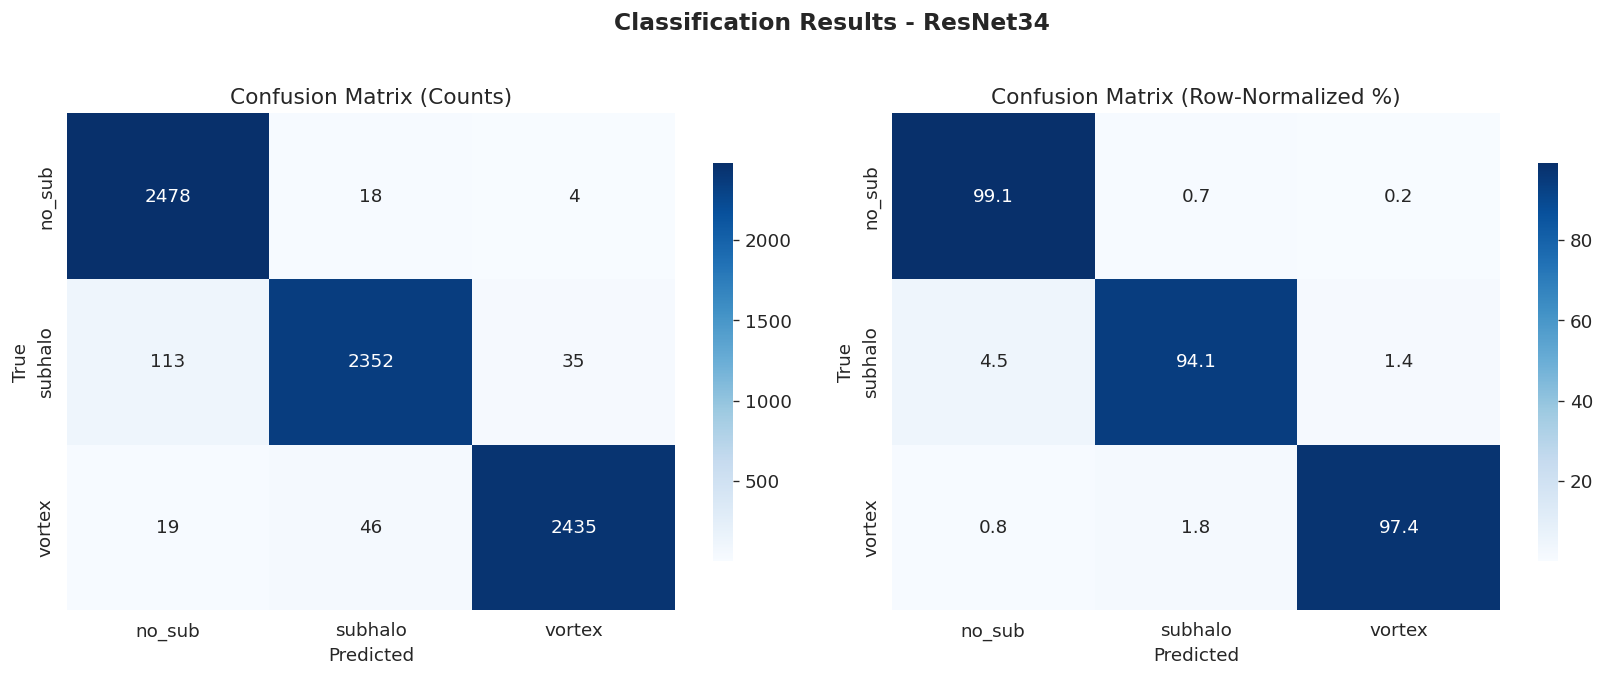

In [ ]:
resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, cfg.num_classes)
resnet = resnet.to(DEVICE)

try:
    resnet = torch.compile(resnet, mode="reduce-overhead")
except Exception as e:
    pass

resnet, resnet_history, resnet_probs, resnet_true = run_training_loop(resnet, "ResNet34")
plot_learning_curves(resnet_history, "ResNet34")
plot_roc_curves(resnet_probs, resnet_true, "ResNet34")
plot_confusion_matrix(resnet_probs, resnet_true, "ResNet34")


# Training Curves:
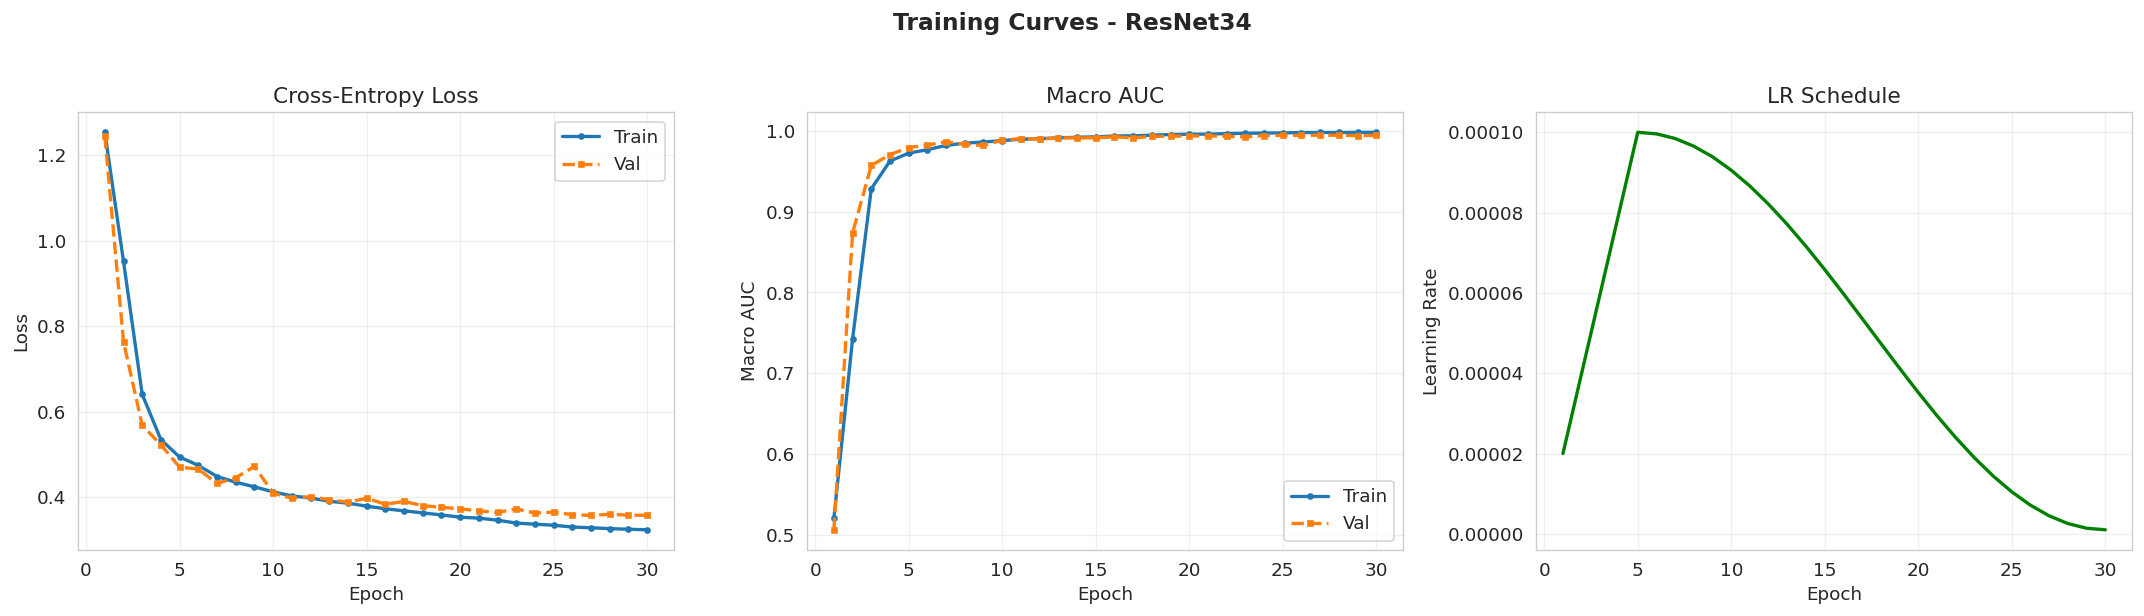

# Common Task 1 Performance Summary:

## Overview
I stuck to ResNet34 as the base model and performed arcsinh strech preprocseeding. trained for 30 epochs, reaching an accuracy of **96.9%**
More detailed metric below:

### Key Performance Metrics
| Metric | Best Validation Value (Epoch 27) | Final Value (Epoch 30) |
| :--- | :---: | :---: |
| **Accuracy** | 96.90% | 96.90% |
| **Macro ROC AUC** | 0.9947 | 0.9943 |
| **Micro ROC AUC** | 0.9952 | 0.9961 |

---

## Detailed Model Evaluation

### ROC AUC Analysis
My model demonstrates exceptional separability across all three classes, with a **Macro-averaged ROC AUC of 0.9947**.

- **no_sub**: 0.9947
- **subhalo**: 0.9920
- **vortex**: 0.9974

### Classification Metrics (Calculated)
Based on the Confusion Matrix counts (Total Samples: 7,500), the following metrics were derived:

| Class | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: |
| **no_sub** | 94.94% | 99.12% | 96.98% |
| **subhalo** | 97.35% | 94.08% | 95.69% |
| **vortex** | 98.42% | 97.40% | 97.91% |
| **Macro Avg** | **96.90%** | **96.87%** | **96.86%** |

### Confusion Matrix Breakdown
The model shows high diagonal density, indicating strong classification performance.

- **no_sub**: 99.1% correct (minimal confusion with `subhalo`)
- **subhalo**: 94.1% correct (most "confused" class, primarily with `no_sub`)
- **vortex**: 97.4% correct (strong performance on interference patterns)

---

## Convergence & Training Dynamics
- **Learning Rate**: The schedule used a warmup to $10^{-4}$ at Epoch 5, followed by a cosine decay to $10^{-8}$.
- **Loss**: Training and validation loss converged steadily around Epoch 25, indicating a well-regularized training run with minimal overfitting.
- **Stability**: Validation AUC peaked early at Epoch 27 (0.9947) and remained stable ($>0.994$) through to Epoch 30.


#ROC Curve:


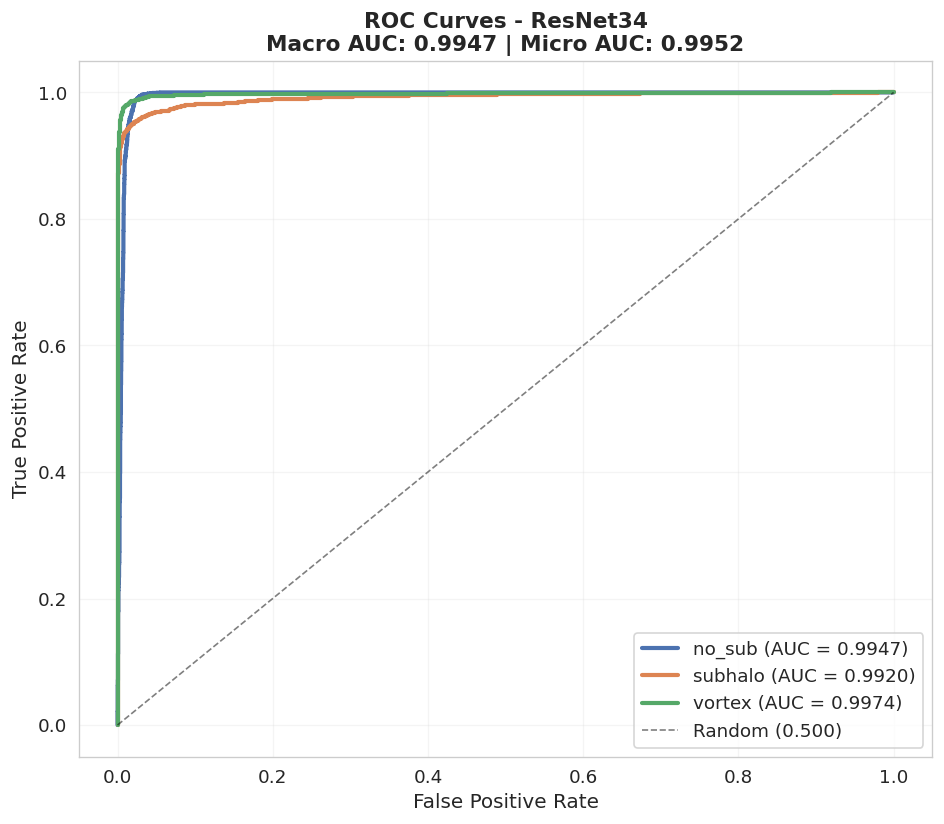

#Confusion Matrices (Count and Row Normalized):
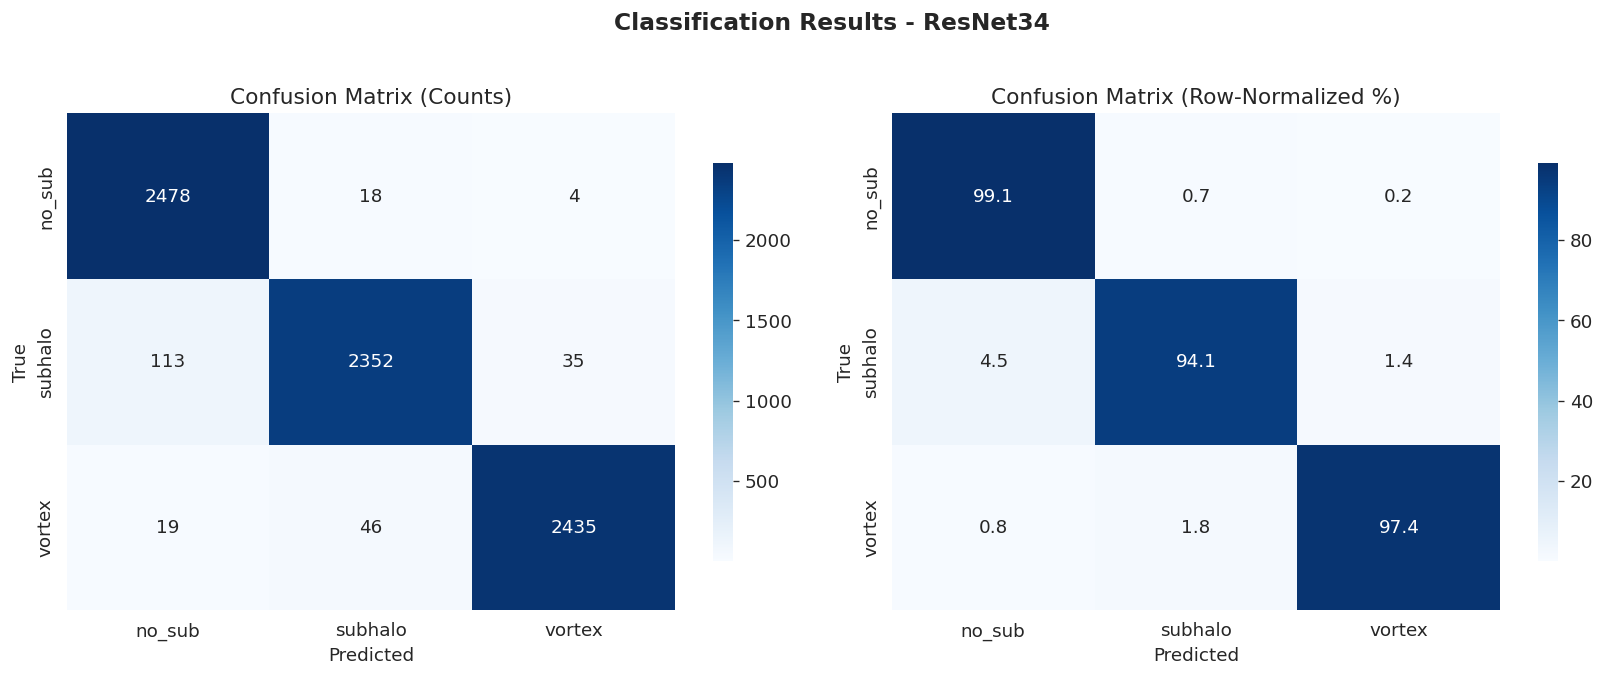